In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score

In [2]:
input_file = (
    "hybrid_quantum_classical_recommendation_results.xlsx"
)

output_file = (
    "personalized_medicine_ranking_results.xlsx"
)

configuration_file = (
    "personalized_medicine_ranking_configuration.json"
)

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"{input_file} was not found.\n"
        "Run the Hybrid Quantum-Classical Model notebook first."
    )

print("Input file found:", input_file)

Input file found: hybrid_quantum_classical_recommendation_results.xlsx


In [3]:
excel_file = pd.ExcelFile(input_file)

print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Model_Comparison', 'Weight_Search', 'Recommendations', 'Classification_Report', 'Confusion_Matrix', 'Class_Mapping', 'Configuration']


In [4]:
recommendations = pd.read_excel(
    input_file,
    sheet_name="Recommendations"
)

print("Dataset shape:", recommendations.shape)
print("\nColumns:")
print(recommendations.columns.tolist())

display(recommendations.head())

Dataset shape: (100, 12)

Columns:
['actual_encoded_target', 'predicted_encoded_target', 'actual_medication_class', 'recommended_medication_class', 'recommendation_confidence', 'recommendation_correct', 'rank_1_medication_class', 'rank_1_score', 'rank_2_medication_class', 'rank_2_score', 'rank_3_medication_class', 'rank_3_score']


,actual_encoded_target,predicted_encoded_target,actual_medication_class,recommended_medication_class,recommendation_confidence,recommendation_correct,rank_1_medication_class,rank_1_score,rank_2_medication_class,rank_2_score,rank_3_medication_class,rank_3_score
0,9,9,Controller inhaler class,Controller inhaler class,0.187092,True,Controller inhaler class,0.187092,Acid-suppression class A,0.178393,Acid-suppression class B,0.165676
1,2,2,Antidiabetic class A,Antidiabetic class A,0.454071,True,Antidiabetic class A,0.454071,Antidiabetic class B,0.336010,Antihypertensive class A,0.069769
2,10,10,Lipid-lowering class A,Lipid-lowering class A,0.588908,True,Lipid-lowering class A,0.588908,Lipid-lowering class B,0.340319,Antihypertensive class B,0.020309
3,10,11,Lipid-lowering class A,Lipid-lowering class B,0.513923,False,Lipid-lowering class B,0.513923,Lipid-lowering class A,0.435276,Antihypertensive class B,0.011188
4,5,0,Antihistamine class B,Acid-suppression class A,0.218595,False,Acid-suppression class A,0.218595,Controller inhaler class,0.217430,Antihistamine class A,0.159957


In [5]:
required_columns = [
    "actual_encoded_target",
    "predicted_encoded_target",
    "actual_medication_class",
    "recommended_medication_class",
    "recommendation_confidence",
    "rank_1_medication_class",
    "rank_1_score",
    "rank_2_medication_class",
    "rank_2_score",
    "rank_3_medication_class",
    "rank_3_score"
]

missing_columns = [
    column
    for column in required_columns
    if column not in recommendations.columns
]

if missing_columns:
    raise KeyError(
        f"Required columns are missing: {missing_columns}"
    )

print("All required ranking columns are available.")

All required ranking columns are available.


In [6]:
score_columns = [
    "rank_1_score",
    "rank_2_score",
    "rank_3_score"
]

recommendations[score_columns] = (
    recommendations[score_columns]
    .apply(pd.to_numeric, errors="coerce")
)

print("Missing score values:")
print(recommendations[score_columns].isnull().sum())

if recommendations[score_columns].isnull().any().any():
    raise ValueError(
        "Missing or invalid recommendation scores were found."
    )

if not (
    recommendations["rank_1_score"]
    >= recommendations["rank_2_score"]
).all():
    raise ValueError(
        "Some Rank 1 scores are lower than Rank 2 scores."
    )

if not (
    recommendations["rank_2_score"]
    >= recommendations["rank_3_score"]
).all():
    raise ValueError(
        "Some Rank 2 scores are lower than Rank 3 scores."
    )

print("Recommendation scores are correctly ordered.")

Missing score values:
rank_1_score    0
rank_2_score    0
rank_3_score    0
dtype: int64
Recommendation scores are correctly ordered.


In [7]:
recommendations = recommendations.copy()

recommendations.insert(
    0,
    "test_profile_id",
    [
        f"TEST-{number:04d}"
        for number in range(
            1,
            len(recommendations) + 1
        )
    ]
)

display(
    recommendations[
        [
            "test_profile_id",
            "actual_medication_class",
            "recommended_medication_class"
        ]
    ].head()
)

,test_profile_id,actual_medication_class,recommended_medication_class
0,TEST-0001,Controller inhaler class,Controller inhaler class
1,TEST-0002,Antidiabetic class A,Antidiabetic class A
2,TEST-0003,Lipid-lowering class A,Lipid-lowering class A
3,TEST-0004,Lipid-lowering class A,Lipid-lowering class B
4,TEST-0005,Antihistamine class B,Acid-suppression class A


In [8]:
recommendations["top_1_top_2_margin"] = (
    recommendations["rank_1_score"]
    - recommendations["rank_2_score"]
)

recommendations["top_2_top_3_margin"] = (
    recommendations["rank_2_score"]
    - recommendations["rank_3_score"]
)

recommendations["top_3_score_total"] = (
    recommendations[
        [
            "rank_1_score",
            "rank_2_score",
            "rank_3_score"
        ]
    ].sum(axis=1)
)

recommendations["normalized_rank_1_score"] = (
    recommendations["rank_1_score"]
    / recommendations["top_3_score_total"]
)

recommendations["normalized_rank_2_score"] = (
    recommendations["rank_2_score"]
    / recommendations["top_3_score_total"]
)

recommendations["normalized_rank_3_score"] = (
    recommendations["rank_3_score"]
    / recommendations["top_3_score_total"]
)

In [9]:
def assign_confidence_level(row):
    confidence = row["recommendation_confidence"]
    margin = row["top_1_top_2_margin"]

    if confidence >= 0.60 and margin >= 0.15:
        return "High"

    if confidence >= 0.35 and margin >= 0.05:
        return "Moderate"

    return "Low"


recommendations["ranking_confidence_level"] = (
    recommendations.apply(
        assign_confidence_level,
        axis=1
    )
)

print(
    recommendations[
        "ranking_confidence_level"
    ].value_counts()
)

ranking_confidence_level
Low         54
Moderate    40
High         6
Name: count, dtype: int64


In [10]:
def find_actual_rank(row):
    actual_class = row["actual_medication_class"]

    ranked_classes = [
        row["rank_1_medication_class"],
        row["rank_2_medication_class"],
        row["rank_3_medication_class"]
    ]

    if actual_class in ranked_classes:
        return ranked_classes.index(actual_class) + 1

    return 0


recommendations["actual_class_rank"] = (
    recommendations.apply(
        find_actual_rank,
        axis=1
    )
)

recommendations["hit_at_1"] = (
    recommendations["actual_class_rank"] == 1
).astype(int)

recommendations["hit_at_2"] = (
    recommendations["actual_class_rank"].between(1, 2)
).astype(int)

recommendations["hit_at_3"] = (
    recommendations["actual_class_rank"].between(1, 3)
).astype(int)

display(
    recommendations[
        [
            "test_profile_id",
            "actual_medication_class",
            "actual_class_rank",
            "hit_at_1",
            "hit_at_2",
            "hit_at_3"
        ]
    ].head(10)
)

,test_profile_id,actual_medication_class,actual_class_rank,hit_at_1,hit_at_2,hit_at_3
0,TEST-0001,Controller inhaler class,1,1,1,1
1,TEST-0002,Antidiabetic class A,1,1,1,1
2,TEST-0003,Lipid-lowering class A,1,1,1,1
3,TEST-0004,Lipid-lowering class A,2,0,1,1
4,TEST-0005,Antihistamine class B,0,0,0,0
5,TEST-0006,Bronchodilator class,2,0,1,1
6,TEST-0007,Antihypertensive class B,2,0,1,1
7,TEST-0008,Antidiabetic class B,1,1,1,1
8,TEST-0009,Antihistamine class B,3,0,0,1
9,TEST-0010,Antihypertensive class A,2,0,1,1


In [11]:
recommendations["reciprocal_rank_at_3"] = np.where(
    recommendations["actual_class_rank"] > 0,
    1.0 / recommendations["actual_class_rank"],
    0.0
)

recommendations["ndcg_at_3"] = np.where(
    recommendations["actual_class_rank"] > 0,
    1.0 / np.log2(
        recommendations["actual_class_rank"] + 1
    ),
    0.0
)

display(
    recommendations[
        [
            "actual_class_rank",
            "reciprocal_rank_at_3",
            "ndcg_at_3"
        ]
    ].head(10)
)

,actual_class_rank,reciprocal_rank_at_3,ndcg_at_3
0,1,1.000000,1.00000
1,1,1.000000,1.00000
2,1,1.000000,1.00000
3,2,0.500000,0.63093
4,0,0.000000,0.00000
5,2,0.500000,0.63093
6,2,0.500000,0.63093
7,1,1.000000,1.00000
8,3,0.333333,0.50000
9,2,0.500000,0.63093


In [12]:
hit_rate_at_1 = recommendations["hit_at_1"].mean()
hit_rate_at_2 = recommendations["hit_at_2"].mean()
hit_rate_at_3 = recommendations["hit_at_3"].mean()

mean_reciprocal_rank_at_3 = (
    recommendations["reciprocal_rank_at_3"].mean()
)

mean_ndcg_at_3 = (
    recommendations["ndcg_at_3"].mean()
)

mean_confidence = (
    recommendations["recommendation_confidence"].mean()
)

mean_top_1_margin = (
    recommendations["top_1_top_2_margin"].mean()
)

ranking_metrics = pd.DataFrame({
    "metric": [
        "Hit Rate@1",
        "Hit Rate@2",
        "Hit Rate@3",
        "MRR@3",
        "NDCG@3",
        "Mean recommendation confidence",
        "Mean top-1/top-2 margin",
        "Total evaluated profiles"
    ],
    "value": [
        hit_rate_at_1,
        hit_rate_at_2,
        hit_rate_at_3,
        mean_reciprocal_rank_at_3,
        mean_ndcg_at_3,
        mean_confidence,
        mean_top_1_margin,
        len(recommendations)
    ]
})

display(ranking_metrics)

,metric,value
0,Hit Rate@1,0.370000
1,Hit Rate@2,0.700000
2,Hit Rate@3,0.860000
3,MRR@3,0.588333
4,NDCG@3,0.658207
5,Mean recommendation confidence,0.360295
6,Mean top-1/top-2 margin,0.126996
7,Total evaluated profiles,100.000000


In [13]:
ranking_rows = []

for _, row in recommendations.iterrows():
    for rank in range(1, 4):
        recommended_class = row[
            f"rank_{rank}_medication_class"
        ]

        raw_score = row[
            f"rank_{rank}_score"
        ]

        normalized_score = row[
            f"normalized_rank_{rank}_score"
        ]

        ranking_rows.append({
            "test_profile_id": row["test_profile_id"],
            "rank": rank,
            "recommended_medication_class": recommended_class,
            "raw_recommendation_score": raw_score,
            "normalized_top_3_score": normalized_score,
            "is_recorded_class": (
                recommended_class
                == row["actual_medication_class"]
            ),
            "ranking_confidence_level": (
                row["ranking_confidence_level"]
            )
        })

personalized_ranking = pd.DataFrame(ranking_rows)

print("Long-format ranking shape:")
print(personalized_ranking.shape)

display(personalized_ranking.head(12))

Long-format ranking shape:
(300, 7)


,test_profile_id,rank,recommended_medication_class,raw_recommendation_score,normalized_top_3_score,is_recorded_class,ranking_confidence_level
0,TEST-0001,1,Controller inhaler class,0.187092,0.352233,True,Low
1,TEST-0001,2,Acid-suppression class A,0.178393,0.335855,False,Low
2,TEST-0001,3,Acid-suppression class B,0.165676,0.311913,False,Low
3,TEST-0002,1,Antidiabetic class A,0.454071,0.528081,True,Moderate
4,TEST-0002,2,Antidiabetic class B,0.336010,0.390778,False,Moderate
5,TEST-0002,3,Antihypertensive class A,0.069769,0.081141,False,Moderate
6,TEST-0003,1,Lipid-lowering class A,0.588908,0.620206,True,Moderate
7,TEST-0003,2,Lipid-lowering class B,0.340319,0.358406,False,Moderate
8,TEST-0003,3,Antihypertensive class B,0.020309,0.021388,False,Moderate
9,TEST-0004,1,Lipid-lowering class B,0.513923,0.535121,False,Moderate


In [14]:
recommendation_frequency = (
    personalized_ranking[
        personalized_ranking["rank"] == 1
    ]
    ["recommended_medication_class"]
    .value_counts()
    .rename_axis("medication_class")
    .reset_index(name="rank_1_recommendation_count")
)

recommendation_frequency[
    "rank_1_recommendation_percentage"
] = (
    recommendation_frequency[
        "rank_1_recommendation_count"
    ]
    / len(recommendations)
    * 100
).round(2)

display(recommendation_frequency)

,medication_class,rank_1_recommendation_count,rank_1_recommendation_percentage
0,Controller inhaler class,14,14.0
1,Antidiabetic class B,11,11.0
2,Lipid-lowering class A,10,10.0
3,Bronchodilator class,10,10.0
4,Antihypertensive class A,9,9.0
5,Antihypertensive class B,9,9.0
6,Antidiabetic class A,8,8.0
7,Antihistamine class B,8,8.0
8,Lipid-lowering class B,7,7.0
9,Acid-suppression class A,5,5.0


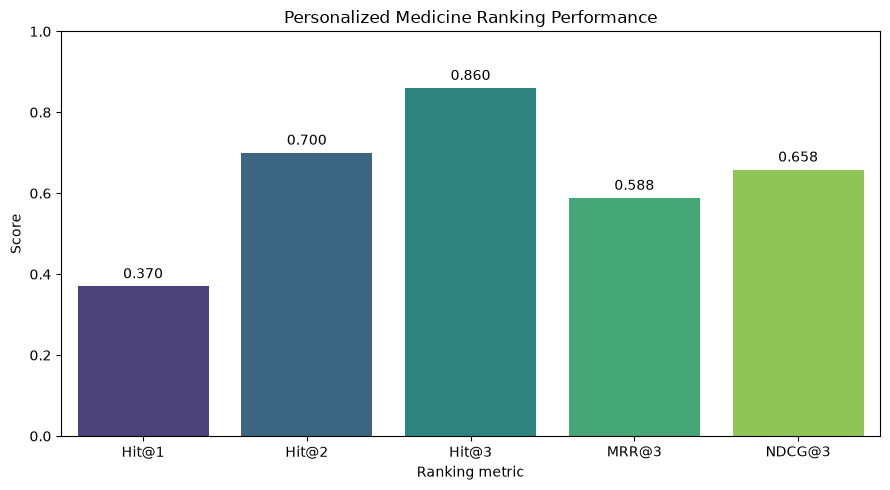

In [15]:
plot_metrics = pd.DataFrame({
    "metric": [
        "Hit@1",
        "Hit@2",
        "Hit@3",
        "MRR@3",
        "NDCG@3"
    ],
    "score": [
        hit_rate_at_1,
        hit_rate_at_2,
        hit_rate_at_3,
        mean_reciprocal_rank_at_3,
        mean_ndcg_at_3
    ]
})

plt.figure(figsize=(9, 5))

sns.barplot(
    data=plot_metrics,
    x="metric",
    y="score",
    hue="metric",
    palette="viridis",
    legend=False
)

plt.ylim(0, 1)
plt.title("Personalized Medicine Ranking Performance")
plt.xlabel("Ranking metric")
plt.ylabel("Score")

for index, score in enumerate(plot_metrics["score"]):
    plt.text(
        index,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [16]:
confidence_summary = (
    recommendations[
        "ranking_confidence_level"
    ]
    .value_counts()
    .rename_axis("confidence_level")
    .reset_index(name="profile_count")
)

confidence_summary["percentage"] = (
    confidence_summary["profile_count"]
    / len(recommendations)
    * 100
).round(2)

display(confidence_summary)

,confidence_level,profile_count,percentage
0,Low,54,54.0
1,Moderate,40,40.0
2,High,6,6.0


In [17]:
assert len(personalized_ranking) == (
    len(recommendations) * 3
)

assert personalized_ranking["rank"].isin(
    [1, 2, 3]
).all()

assert recommendations[
    "actual_class_rank"
].isin([0, 1, 2, 3]).all()

assert (
    personalized_ranking[
        "normalized_top_3_score"
    ]
    .between(0, 1)
    .all()
)

normalized_sums = (
    personalized_ranking
    .groupby("test_profile_id")[
        "normalized_top_3_score"
    ]
    .sum()
)

assert np.allclose(
    normalized_sums,
    1.0,
    atol=1e-6
)

print("All personalized ranking checks passed.")

All personalized ranking checks passed.


In [18]:
configuration = {
    "stage": "Personalized Medicine Ranking",
    "input_file": input_file,
    "number_of_profiles": int(len(recommendations)),
    "recommendations_per_profile": 3,
    "ranking_method": (
        "Descending hybrid quantum-classical probability"
    ),
    "evaluation_metrics": [
        "Hit Rate@1",
        "Hit Rate@2",
        "Hit Rate@3",
        "MRR@3",
        "NDCG@3"
    ],
    "hit_rate_at_1": float(hit_rate_at_1),
    "hit_rate_at_2": float(hit_rate_at_2),
    "hit_rate_at_3": float(hit_rate_at_3),
    "mrr_at_3": float(mean_reciprocal_rank_at_3),
    "ndcg_at_3": float(mean_ndcg_at_3)
}

with open(configuration_file, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    recommendations.to_excel(
        writer,
        sheet_name="Profile_Recommendations",
        index=False
    )

    personalized_ranking.to_excel(
        writer,
        sheet_name="Ranking_Long_Format",
        index=False
    )

    ranking_metrics.to_excel(
        writer,
        sheet_name="Ranking_Metrics",
        index=False
    )

    recommendation_frequency.to_excel(
        writer,
        sheet_name="Recommendation_Frequency",
        index=False
    )

    confidence_summary.to_excel(
        writer,
        sheet_name="Confidence_Summary",
        index=False
    )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved ranking results:", output_file)
print("Saved configuration:", configuration_file)

Saved ranking results: personalized_medicine_ranking_results.xlsx
Saved configuration: personalized_medicine_ranking_configuration.json


In [19]:
required_output_files = [
    output_file,
    configuration_file
]

for file_name in required_output_files:
    print(
        file_name,
        "exists:",
        os.path.exists(file_name)
    )

saved_workbook = pd.ExcelFile(output_file)

print("\nSaved sheets:")
print(saved_workbook.sheet_names)

print("\nFinal ranking results")
print("Hit Rate@1:", round(hit_rate_at_1, 4))
print("Hit Rate@2:", round(hit_rate_at_2, 4))
print("Hit Rate@3:", round(hit_rate_at_3, 4))
print("MRR@3:", round(mean_reciprocal_rank_at_3, 4))
print("NDCG@3:", round(mean_ndcg_at_3, 4))

personalized_medicine_ranking_results.xlsx exists: True
personalized_medicine_ranking_configuration.json exists: True

Saved sheets:
['Profile_Recommendations', 'Ranking_Long_Format', 'Ranking_Metrics', 'Recommendation_Frequency', 'Confidence_Summary', 'Configuration']

Final ranking results
Hit Rate@1: 0.37
Hit Rate@2: 0.7
Hit Rate@3: 0.86
MRR@3: 0.5883
NDCG@3: 0.6582
